step 1: Loading the Dataset



In [ ]:
import pandas as pd
from google.colab import files

# Upload dataset
uploaded = files.upload()

# Get uploaded file name
file_name = list(uploaded.keys())[0]

# Read CSV file
df = pd.read_csv(file_name)

# Check dataset
print("Dataset loaded successfully!")
print("Shape:", df.shape)

# Show first 5 rows
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (2).csv
Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


step 2: Exploring the Dataset

In [ ]:
# Column names
print("Column Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Basic statistics
print("\nBasic Statistics:")
display(df.describe())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Basic Statistics:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


step 3: Checking missing values and duplicates

In [ ]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows: 0


step 4: customer churn distribution

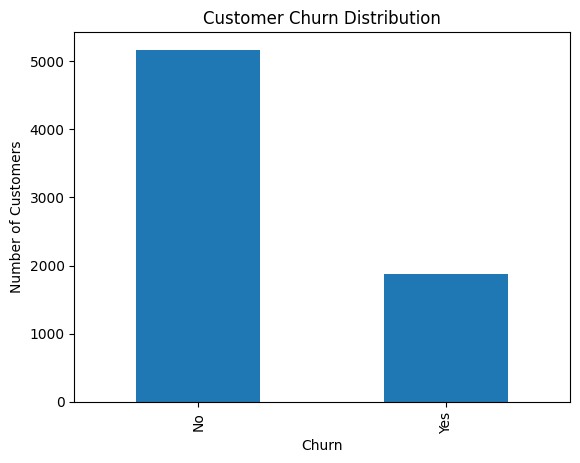

In [ ]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

step 5: exploratory data analysis-Churn by contract type

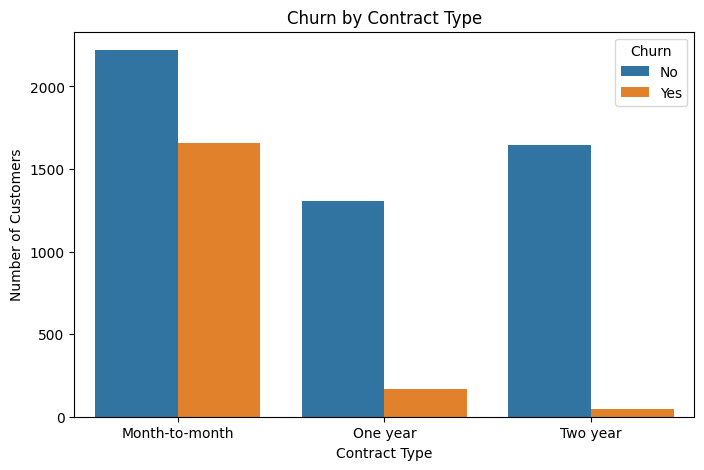

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

step 6: data cleaning

In [ ]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values again
print("Missing values:")
print(df.isnull().sum())

# Fill missing TotalCharges with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("\nCleaning completed!")

Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Cleaning completed!


step 7: feature engineering and data preparation

In [ ]:
# Remove customer ID
df = df.drop("customerID", axis=1)

# Convert Churn into 0 and 1
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Convert categorical columns into numbers
df = pd.get_dummies(df, drop_first=True)

# Separate input features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nData is ready for Machine Learning!")

X shape: (7043, 30)
y shape: (7043,)

Data is ready for Machine Learning!


step 8: spliting data into training and testing set

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


step 9: training machine learning models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Logistic Regression
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Both models trained successfully!")

Both models trained successfully!


step 10. Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predictions
log_pred = log_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Logistic Regression Results
print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1 Score:", f1_score(y_test, log_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))

# Random Forest Results
print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

===== Logistic Regression =====
Accuracy: 0.8069552874378992
Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1 Score: 0.6091954022988506
Confusion Matrix:
[[925 110]
 [162 212]]

===== Random Forest =====
Accuracy: 0.7849538679914834
Precision: 0.6179401993355482
Recall: 0.49732620320855614
F1 Score: 0.5511111111111111
Confusion Matrix:
[[920 115]
 [188 186]]


step 11. Churn Prediction for a Sample Customer

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred)
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195
1,Random Forest,0.784954,0.617940,0.497326,0.551111


step 12: Confusion Matrix – Logistic Regression

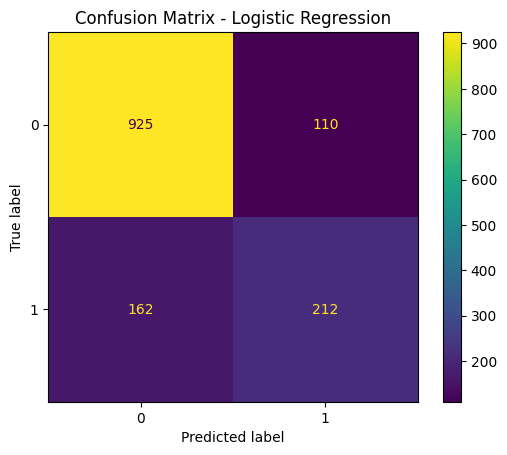

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, log_pred)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

step 13: Customer Churn Prediction for a Sample Customer

In [ ]:
# Select one sample customer from test data
sample_customer = X_test.iloc[[0]]

# Predict churn
prediction = log_model.predict(sample_customer)[0]

if prediction == 1:
    print("Prediction: Customer will Churn")
else:
    print("Prediction: Customer will Not Churn")

Prediction: Customer will Not Churn


conclusion:

 In this project, I worked on predicting customer churn using machine learning. First, I loaded and cleaned the dataset and checked the missing values and data types. Then I performed some basic analysis to understand the customers and their churn behavior. After preprocessing the data, I trained two models, Logistic Regression and Random Forest. I compared their Accuracy, Precision, Recall, and F1 Score. In my results, Logistic Regression performed better than Random Forest. Finally, I used the model to predict whether a sample customer would churn or not. Overall, this project helped me understand the basic steps of using machine learning for customer churn prediction.